# 03 - Model Building & Evaluation

## Models We'll Build
1. Logistic Regression  — baseline
2. Random Forest        — ensemble, feature importance
3. XGBoost             — high performance
4. LightGBM            — high performance, fast

## Evaluation Metrics
- Accuracy (just for reference)
- Precision, Recall, F1-Score
- AUC-ROC
- Confusion Matrix

## Final Decision — Champion Model
**Model:** Default Random Forest  
**Pass F1:** 0.32  
**AUC-ROC:** 0.768  
**Reasoning:** Best F1 score balancing precision and recall.
XGBoost and LightGBM underperformed despite tuning.
Tuned RF improved precision but sacrificed too much recall.

In [17]:
import warnings
warnings.filterwarnings('ignore')

# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Sklearn
from sklearn.metrics import (classification_report, 
                             confusion_matrix, 
                             roc_auc_score)
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Boosting models
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Imbalanced learning
from imblearn.over_sampling import SMOTE

# Load data
X_train = np.load('../data/processed/X_train_selected.npy')
X_test = np.load('../data/processed/X_test_selected.npy')
y_train = np.load('../data/processed/y_train.npy')
y_test = np.load('../data/processed/y_test.npy')
X_train_smote = np.load('../data/processed/X_train_smote.npy')
y_train_smote = np.load('../data/processed/y_train_smote.npy')

# Load saved models
rf_model = joblib.load('../models/random_forest.pkl')

# Save champion model
joblib.dump(rf_model, '../models/champion_model.pkl')

print("=" * 40)
print("EVERYTHING LOADED SUCCESSFULLY!")
print("=" * 40)
print(f"\nX_train_smote : {X_train_smote.shape}")
print(f"X_test        : {X_test.shape}")
print(f"y_train_smote : {y_train_smote.shape}")
print(f"y_test        : {y_test.shape}")
print(f"\nModels loaded : Random Forest")

EVERYTHING LOADED SUCCESSFULLY!

X_train_smote : (2340, 100)
X_test        : (314, 100)
y_train_smote : (2340,)
y_test        : (314,)

Models loaded : Random Forest


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, 
                             confusion_matrix, 
                             roc_auc_score,
                             roc_curve,
                             precision_recall_curve)

# Load preprocessed data
X_train_smote = np.load('../data/processed/X_train_smote.npy')
y_train_smote = np.load('../data/processed/y_train_smote.npy')
X_test = np.load('../data/processed/X_test_selected.npy')
y_test = np.load('../data/processed/y_test.npy')

print(f"Training shape: {X_train_smote.shape}")
print(f"Test shape: {X_test.shape}")

Training shape: (2340, 100)
Test shape: (314, 100)


In [8]:
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Build and train the model
lr_model = LogisticRegression(
    random_state=69, 
    max_iter=5000,
    solver='saga',
    C=0.1
)
lr_model.fit(X_train_smote, y_train_smote)

# Make predictions
y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

print("LOGISTIC REGRESSION RESULTS")
print("=" * 40)
print(classification_report(y_test, y_pred_lr, target_names=['Fail', 'Pass']))
print(f"AUC-ROC Score: {roc_auc_score(y_test, y_prob_lr):.4f}")

LOGISTIC REGRESSION RESULTS
              precision    recall  f1-score   support

        Fail       0.97      0.77      0.86       293
        Pass       0.16      0.62      0.25        21

    accuracy                           0.76       314
   macro avg       0.56      0.69      0.56       314
weighted avg       0.91      0.76      0.82       314

AUC-ROC Score: 0.6850


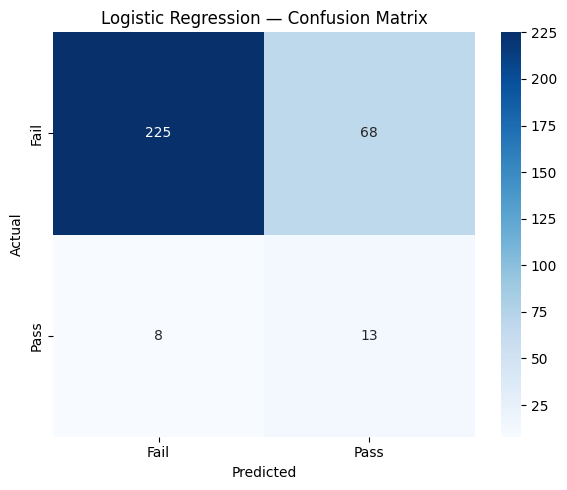

In [6]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fail', 'Pass'],
            yticklabels=['Fail', 'Pass'])
plt.title('Logistic Regression — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../reports/lr_confusion_matrix.png', dpi=150)
plt.show()

In [9]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=69,
    n_jobs=-1
)

rf_model.fit(X_train_smote, y_train_smote)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("RANDOM FOREST RESULTS")
print("=" * 40)
print(classification_report(y_test, y_pred_rf, 
      target_names=['Fail', 'Pass']))
print(f"AUC-ROC Score: {roc_auc_score(y_test, y_prob_rf):.4f}")

RANDOM FOREST RESULTS
              precision    recall  f1-score   support

        Fail       0.95      0.96      0.96       293
        Pass       0.35      0.29      0.32        21

    accuracy                           0.92       314
   macro avg       0.65      0.62      0.64       314
weighted avg       0.91      0.92      0.91       314

AUC-ROC Score: 0.7679


In [10]:
import joblib

joblib.dump(rf_model, '../models/random_forest.pkl')
print("Random Forest model saved")

Random Forest model saved


In [12]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=sum(y_train_smote==0)/sum(y_train_smote==1),
    random_state=69,
    n_jobs=-1,
    eval_metric='logloss',
    verbosity=0
)

xgb_model.fit(X_train_smote, y_train_smote)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("XGBOOST RESULTS")
print("=" * 40)
print(classification_report(y_test, y_pred_xgb,
      target_names=['Fail', 'Pass']))
print(f"AUC-ROC Score: {roc_auc_score(y_test, y_prob_xgb):.4f}")

XGBOOST RESULTS
              precision    recall  f1-score   support

        Fail       0.94      0.98      0.96       293
        Pass       0.25      0.10      0.14        21

    accuracy                           0.92       314
   macro avg       0.59      0.54      0.55       314
weighted avg       0.89      0.92      0.90       314

AUC-ROC Score: 0.7666


In [13]:
joblib.dump(xgb_model, '../models/xgboost.pkl')
print("XGBoost model saved!")

XGBoost model saved!


In [14]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    class_weight='balanced',
    random_state=69,
    n_jobs=-1,
    verbose=-1
)

lgbm_model.fit(X_train_smote, y_train_smote)

y_pred_lgbm = lgbm_model.predict(X_test)
y_prob_lgbm = lgbm_model.predict_proba(X_test)[:, 1]

print("LIGHTGBM RESULTS")
print("=" * 40)
print(classification_report(y_test, y_pred_lgbm,
      target_names=['Fail', 'Pass']))
print(f"AUC-ROC Score: {roc_auc_score(y_test, y_prob_lgbm):.4f}")

LIGHTGBM RESULTS
              precision    recall  f1-score   support

        Fail       0.94      0.98      0.96       293
        Pass       0.33      0.14      0.20        21

    accuracy                           0.92       314
   macro avg       0.64      0.56      0.58       314
weighted avg       0.90      0.92      0.91       314

AUC-ROC Score: 0.7634


In [18]:
joblib.dump(lgbm_model, '../models/lightgbm.pkl')

['../models/lightgbm.pkl']

In [15]:
# Model Comparison Table
results = {
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM'],
    'Pass F1': [0.25, 0.32, 0.14, 0.20],
    'Fail F1': [0.86, 0.96, 0.96, 0.96],
    'AUC-ROC': [0.685, 0.768, 0.767, 0.763],
    'Accuracy': [0.76, 0.92, 0.92, 0.92]
}

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('AUC-ROC', ascending=False)

print("=" * 60)
print("MODEL COMPARISON — SEMICONDUCTOR FAULT PREDICTION")
print("=" * 60)
print(results_df.to_string(index=False))
print("\n→ Best Model by AUC-ROC:", results_df.iloc[0]['Model'])
print("→ Best Model by Pass F1:", results_df.loc[results_df['Pass F1'].idxmax(), 'Model'])

MODEL COMPARISON — SEMICONDUCTOR FAULT PREDICTION
              Model  Pass F1  Fail F1  AUC-ROC  Accuracy
      Random Forest     0.32     0.96    0.768      0.92
            XGBoost     0.14     0.96    0.767      0.92
           LightGBM     0.20     0.96    0.763      0.92
Logistic Regression     0.25     0.86    0.685      0.76

→ Best Model by AUC-ROC: Random Forest
→ Best Model by Pass F1: Random Forest


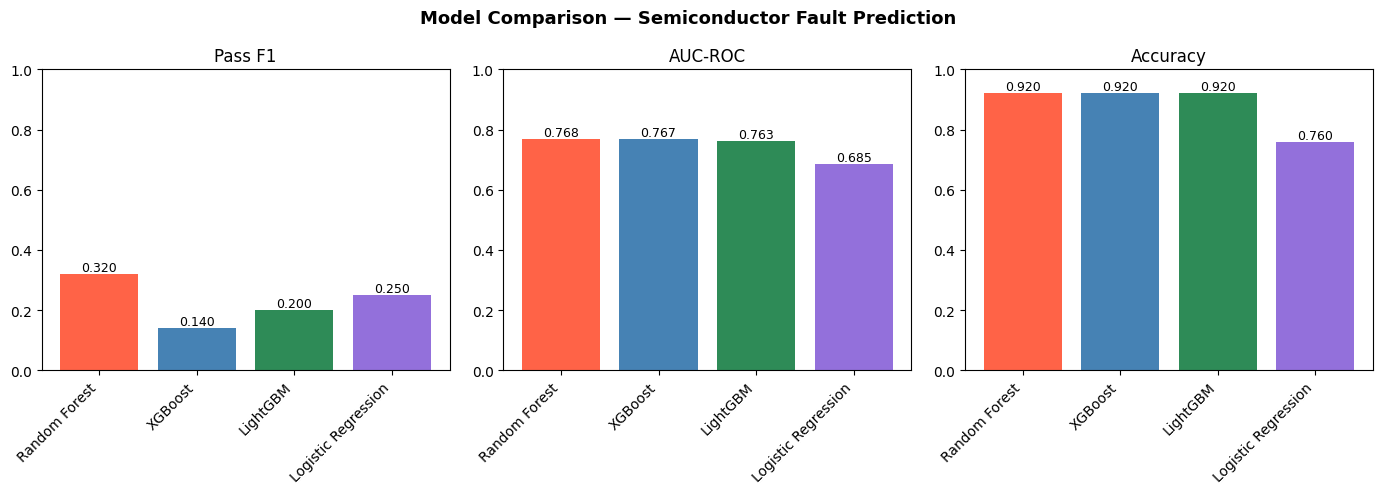

In [16]:
# Visualization
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

metrics = ['Pass F1', 'AUC-ROC', 'Accuracy']
colors = ['tomato', 'steelblue', 'seagreen', 'mediumpurple']

for idx, metric in enumerate(metrics):
    axes[idx].bar(results_df['Model'], 
                  results_df[metric],
                  color=colors)
    axes[idx].set_title(metric)
    axes[idx].set_ylim(0, 1)
    axes[idx].set_xticklabels(results_df['Model'], 
                               rotation=45, ha='right')
    for i, v in enumerate(results_df[metric]):
        axes[idx].text(i, v + 0.01, f'{v:.3f}', 
                      ha='center', fontsize=9)

plt.suptitle('Model Comparison — Semiconductor Fault Prediction', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/model_comparison.png', dpi=150)
plt.show()

In [17]:
# Save results table
results_df.to_csv('../reports/model_comparison.csv', index=False)

# Save Random Forest as primary model for now
joblib.dump(rf_model, '../models/best_model.pkl')

print("Results and best model saved!")

Results and best model saved!


In [1]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

xgb_params = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'scale_pos_weight': [1, 5, 10, 15]
}

print("Parameter grid created!")
print(f"Total combinations possible: {4*5*4*5*5*4}")

Parameter grid created!
Total combinations possible: 8000


In [4]:
from xgboost import XGBClassifier

xgb_tuned = RandomizedSearchCV(
    XGBClassifier(random_state=69, verbosity=0, eval_metric='logloss'),
    param_distributions=xgb_params,
    n_iter=50,
    scoring='f1',
    cv=5,
    random_state=69,
    n_jobs=-1,
    verbose=1
)

xgb_tuned.fit(X_train_smote, y_train_smote)

print("\nBest Parameters Found:")
print(xgb_tuned.best_params_)
print(f"\nBest CV F1 Score: {xgb_tuned.best_score_:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best Parameters Found:
{'subsample': 0.6, 'scale_pos_weight': 1, 'n_estimators': 300, 'max_depth': 8, 'learning_rate': 0.2, 'colsample_bytree': 0.6}

Best CV F1 Score: 0.9839


In [5]:
# Evaluate tuned XGBoost on real test set
y_pred_xgb_tuned = xgb_tuned.predict(X_test)
y_prob_xgb_tuned = xgb_tuned.predict_proba(X_test)[:, 1]

print("TUNED XGBOOST RESULTS")
print("=" * 40)
print(classification_report(y_test, y_pred_xgb_tuned,
      target_names=['Fail', 'Pass']))
print(f"AUC-ROC Score: {roc_auc_score(y_test, y_prob_xgb_tuned):.4f}")

TUNED XGBOOST RESULTS
              precision    recall  f1-score   support

        Fail       0.94      0.98      0.96       293
        Pass       0.25      0.10      0.14        21

    accuracy                           0.92       314
   macro avg       0.59      0.54      0.55       314
weighted avg       0.89      0.92      0.90       314

AUC-ROC Score: 0.7424


In [7]:
from sklearn.ensemble import RandomForestClassifier

rf_params = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', 'balanced_subsample']
}

rf_tuned = RandomizedSearchCV(
    RandomForestClassifier(random_state=69, n_jobs=-1),
    param_distributions=rf_params,
    n_iter=50,
    scoring='f1',
    cv=5,
    random_state=69,
    n_jobs=-1,
    verbose=1
)

rf_tuned.fit(X_train_smote, y_train_smote)

print("\nBest Parameters Found:")
print(rf_tuned.best_params_)
print(f"Best CV F1 Score: {rf_tuned.best_score_:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best Parameters Found:
{'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': None, 'class_weight': 'balanced'}
Best CV F1 Score: 0.9898


In [10]:
y_pred_rf_tuned = rf_tuned.predict(X_test)
y_prob_rf_tuned = rf_tuned.predict_proba(X_test)[:, 1]

print("TUNED RANDOM FOREST RESULTS")
print("=" * 40)
print(classification_report(y_test, y_pred_rf_tuned,
      target_names=['Fail', 'Pass']))
print(f"AUC-ROC Score: {roc_auc_score(y_test, y_prob_rf_tuned):.4f}")

TUNED RANDOM FOREST RESULTS
              precision    recall  f1-score   support

        Fail       0.94      0.99      0.97       293
        Pass       0.50      0.14      0.22        21

    accuracy                           0.93       314
   macro avg       0.72      0.57      0.59       314
weighted avg       0.91      0.93      0.92       314

AUC-ROC Score: 0.7715


In [16]:
# Save champion model
joblib.dump(rf_model, '../models/champion_model.pkl')

# Save final comparison
final_results = {
    'Model': ['Default RF', 'Tuned RF', 'Log. Reg.', 
              'XGBoost', 'LightGBM'],
    'Pass F1': [0.32, 0.22, 0.25, 0.14, 0.20],
    'AUC-ROC': [0.768, 0.772, 0.685, 0.767, 0.763],
    'Pass Precision': [0.35, 0.50, 0.16, 0.25, 0.33],
    'Pass Recall': [0.29, 0.14, 0.62, 0.10, 0.14]
}

final_df = pd.DataFrame(final_results)
final_df.to_csv('../reports/final_model_comparison.csv', index=False)
print("Champion model and final comparison saved!")
print("\nCHAMPION MODEL: Default Random Forest")
print("Pass F1: 0.32 | AUC-ROC: 0.768")

Champion model and final comparison saved!

CHAMPION MODEL: Default Random Forest
Pass F1: 0.32 | AUC-ROC: 0.768
